# Module 1b · Predicting Catalyst Stability: Same Template, New Target

This is the stability counterpart to Module 1a. Same recipe-table to ML pipeline, but the target is now `Log(Decay Rate)` (mV/h): how fast the catalyst degrades under operation, where lower means more stable, instead of activity.

The lesson is that the same feature-engineering and modeling template transfers to a brand-new target. The reasoning behind each step (element-to-property features, metrics, SHAP) was covered in Module 1a, so here we move faster and focus on what changes for stability and on reproducing the paper.

What changes vs 1a: a different file and encoding (UTF-8), a smaller dataset (345 high-quality rows), stability-specific test columns (current density, test time), and a different label and split seed.

## 0. Setup

In [ ]:
# Colab setup: fetch the data and enter this module's folder. No-op when run locally.
import os, sys
REPO = "https://github.com/ruiding-uchicago/NRT_Training_Materials.git"
MODULE = "module_1_tabular_ML"
if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != MODULE:
    root = "/content/NRT_Training_Materials"
    if not os.path.isdir(root):
        os.system("git clone --depth 1 " + REPO + " " + root)
    os.chdir(root + "/" + MODULE)
print("ready in", os.getcwd())

In [1]:
import sys, subprocess, os
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap", "xgboost"])
os.makedirs("figures", exist_ok=True)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
RND = 42

## 1. Read the table: note the different encoding

Module 1a's file was GBK; this one is UTF-8 with a BOM. A reminder to always check the encoding instead of assuming. The label is `Log (Decay Rate) (mV/h)`, the log₁₀ of the voltage-decay rate, where lower is more stable and negative means extremely stable.

In [2]:
DATA_PATH = "OER_stability.csv"           # Colab: upload the file, then point this to it
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")   # UTF-8 here (1a was GBK)
print("shape:", df.shape)
df.head(3)

shape: (453, 39)


,DOI,Country,Facility,Journal,Impact Factor,Published Date,Cited Times,Number of days until 01/20/2023,Average cited times per day,Metal_Dopant_1,...,Annealing Atomosphere Reductive (0/1),Post-processing Acid Wash etc. (0/1),Catalyst Loading (mg cm -2),Support Material Loading (mg cm -2),Support is not Carbon (0/1),Electrode Type_Glassy Carbon/Carbon Paper or Ti Mesh (0/1),Electrolyte Proton Concentration (M),Stability Current Density (mA cm-2),Stability Test Time (h),Log (Decay Rate) (mV/h)
0,10.1016/j.jallcom.2021.162113,Peoples R China,Qufu Normal Univ,JOURNAL OF ALLOYS AND COMPOUNDS,6.371,10/21/2021,4,456,0.008772,Cu,...,0,0,0.704,0.000,0,0,1.0,10.0,24.0,0.432969
1,10.1016/j.apcatb.2021.120899,Taiwan,Natl Tsing Hua Univ,APPLIED CATALYSIS B-ENVIRONMENTAL,24.319,11/27/2021,11,419,0.026253,Co,...,0,0,0.902,0.198,0,1,1.0,10.0,25.0,0.447158
2,10.1016/j.apcatb.2021.120899,Taiwan,Natl Tsing Hua Univ,APPLIED CATALYSIS B-ENVIRONMENTAL,24.319,11/27/2021,11,419,0.026253,Co,...,0,0,0.902,0.198,0,1,1.0,10.0,30.0,0.698970


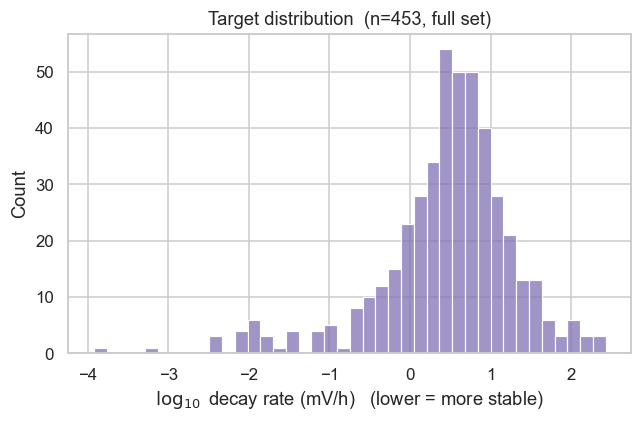

count    453.000
mean       0.445
std        0.860
min       -3.920
25%        0.097
50%        0.563
75%        0.912
max        2.427
Name: Log (Decay Rate) (mV/h), dtype: float64

In [3]:
TARGET = "Log (Decay Rate) (mV/h)"
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df[TARGET], bins=40, color="#8172B3", ax=ax)
ax.set(xlabel=r"$\log_{10}$ decay rate (mV/h)   (lower = more stable)", ylabel="Count",
       title=f"Target distribution  (n={len(df)}, full set)")
fig.tight_layout(); fig.savefig("figures/1b_01_target_hist.png", dpi=150); plt.show()
df[TARGET].describe().round(3)

Same bibliometric high-quality filter as 1a (Impact Factor ≥ 10, avg. citations/day ≥ 0.025, or published within 365 days of 2023-01-20). Stability data is scarcer, so the subset is only 345 rows.

In [4]:
hq = ((df["Impact Factor"] >= 10) |
      (df["Average cited times per day"] >= 0.025) |
      (df["Number of days until 01/20/2023"] <= 365))
n0 = len(df); df = df[hq].reset_index(drop=True)
print(f"High-quality subset: {n0} -> {len(df)} rows")

High-quality subset: 453 -> 345 rows


## 2. Feature engineering: identical to 1a

Same element-to-8-property mapping, and the same four feature groups as 1a (element identity 32, composition 4, synthesis 12, electrode-and-testing 7, for 55 total). The only change is the testing group: it adds the stability current density and test time, and drops the activity-only LSV scan speed. A different `TARGET` and `META_DROP` handle the rest.

In [5]:
# element -> [rel. atomic mass, atomic number, period, group, ionization energy, electronegativity, # d-electrons, atomic radius]
PROPS = ["Relative Atomic Mass","Atomic Number","Period","Group",
         "Ionization Potential","Electronegativity","Number of d electrons","Atomic Radius"]
element_information = {
"None":[0,0,0,0,0,0,0,0], "none":[0,0,0,0,0,0,0,0],
"Li":[6.941,3,2,1,5.37,0.98,0,145], "B":[10.811,5,2,13,8.33,2.04,0,98],
"C":[12.0107,6,2,14,11.22,2.56,0,77], "N":[14.0067,7,2,15,14.48,3.04,0,92],
"F":[18.9984,9,2,17,18.6,3.98,0,73], "Na":[22.9897,11,3,1,5.12,0.93,0,190],
"Mg":[24.3050,12,3,2,7.61,1.31,0,160], "Al":[26.9815,13,3,13,5.95,1.61,0,143],
"Si":[28.0855,14,3,14,8.12,1.9,0,132], "P":[30.9737,15,3,15,10.3,2.19,0,128],
"S":[32.065,16,3,16,10.31,2.58,0,127], "Cl":[35.453,17,3,17,12.96,3.16,0,99],
"K":[39.0983,19,4,1,4.32,0.82,0,235], "Ca":[40.078,20,4,2,6.09,1.0,0,197],
"Sc":[44.956,21,4,3,6.57,1.36,1,162], "Ti":[47.867,22,4,4,6.81,1.54,2,147],
"V":[50.942,23,4,5,6.76,1.63,3,134], "Cr":[51.996,24,4,6,6.74,1.66,4,130],
"Mn":[54.938,25,4,7,7.4,1.56,5,127], "Fe":[55.845,26,4,8,7.83,1.83,6,126],
"Co":[58.933,27,4,9,7.81,1.88,7,125], "Ni":[58.6934,28,4,10,7.61,1.91,8,124],
"Cu":[63.546,29,4,11,7.69,1.9,10,128], "Zn":[65.38,30,4,12,9.35,1.65,10,138],
"Ga":[69.723,31,4,13,5.97,1.81,10,141], "Se":[78.96,34,4,16,9.5,2.55,10,140],
"Br":[79.904,35,4,17,11.8,2.96,10,115], "Sr":[87.62,38,5,2,5.67,0.95,10,215],
"Y":[88.905,39,5,3,6.5,1.22,1,178], "Zr":[91.224,40,5,4,6.0,1.33,2,160],
"Nb":[92.906,41,5,5,6.76,1.6,4,146], "Mo":[95.94,42,5,6,7.35,2.16,5,139],
"Tc":[98.906,43,5,7,7.28,1.9,5,136], "Ru":[101.07,44,5,8,7.5,2.2,7,134],
"Rh":[102.905,45,5,9,7.7,2.28,8,134], "Pd":[106.42,46,5,10,8.3,2.2,10,137],
"Ag":[107.868,47,5,11,7.54,1.93,10,144], "Cd":[112.411,48,5,12,8.95,1.69,10,154],
"In":[114.818,49,5,13,8.95,1.78,10,166], "Sn":[118.71,50,5,14,7.37,1.96,10,162],
"Sb":[121.760,51,5,15,8.35,2.05,10,159], "Te":[127.6,52,5,16,9.0096,2.1,10,160],
"Ba":[137.327,56,6,2,5.19,0.89,10,222], "La":[138.905,57,6,3,5.5,1.1,1,187],
"Ce":[140.116,58,6,3,6.91,1.12,1,181], "Pr":[140.904,59,6,3,5.76,1.13,10,182],
"Nd":[144.242,60,6,3,6.31,1.14,10,182], "Sm":[150.36,62,6,3,6.55,1.1,10,181],
"Eu":[151.964,63,6,3,5.67,1.2,10,199], "Gd":[157.25,64,6,3,6.65,1.2,1,179],
"Tb":[158.925,65,6,3,6.74,1.2,10,180], "Ho":[164.93,67,6,3,6.022,1.23,10,179],
"Er":[167.529,68,6,3,6.108,1.23,10,178], "Tm":[168.934,69,6,3,6.184,1.25,10,177],
"Lu":[174.967,71,6,3,5.4259,1.27,1,175], "Ta":[180.947,73,6,5,7.89,1.5,3,149],
"W":[183.84,74,6,6,7.98,2.36,4,141], "Os":[190.23,76,6,8,8.7,2.2,6,135],
"Ir":[192.217,77,6,9,9.1,2.2,7,136], "Pt":[195.084,78,6,10,8.9,2.28,9,139],
"Au":[196.966,79,6,11,9.19,2.54,10,144], "Pb":[207.2,82,6,14,7.38,2.33,10,175],
"Bi":[208.98,83,6,15,7.25,2.02,10,170],
}

ELEMENT_COLS = ["Metal_Dopant_1","Metal_Dopant_2","Metal_Dopant_3","Metal_Dopant_4"]
# same idea as 1a; note: no 'Electrolyte O2 Saturated' here, and the stability-test columns are KEPT as features
META_DROP = ["DOI","Country","Facility","Journal","Impact Factor","Published Date",
    "Cited Times","Number of days until 01/20/2023","Average cited times per day",
    "Annealing Temerature Rising Rate (Celcius Degree min-1)","Sample Name"]

def featurize(frame):
    frame = frame.copy()
    seen = pd.unique(frame[ELEMENT_COLS].fillna("None").astype(str).values.ravel())
    missing = [e for e in seen if e not in element_information]
    if missing: print("WARNING: elements not in table (set to 0):", missing)
    blocks = []
    for slot, col in enumerate(ELEMENT_COLS, start=1):
        mapped = frame[col].fillna("None").astype(str).map(
            lambda e: element_information.get(e, element_information["None"]))
        blocks.append(pd.DataFrame(mapped.tolist(),
            columns=[f"M{slot}:{p}" for p in PROPS], index=frame.index))
    X_elem = pd.concat(blocks, axis=1)
    cond_cols = [c for c in frame.columns if c not in META_DROP + ELEMENT_COLS + [TARGET]]
    X_cond = frame[cond_cols].apply(pd.to_numeric, errors="coerce")
    X = pd.concat([X_elem, X_cond], axis=1).fillna(0.0)
    X.columns = [re.sub(r"[\[\]<>]", "", str(c)).strip() for c in X.columns]
    y = frame[TARGET].astype(float)
    return X, y

X, y = featurize(df)
print("feature matrix:", X.shape, "(32 element props + 4 proportions + 19 conditions = 55 features)")
print("non-element features:", [c for c in X.columns if not c.startswith(("M1:", "M2:", "M3:", "M4:"))])
X.head(3)

feature matrix: (345, 55) (32 element props + 4 proportions + 19 conditions = 55 features)
non-element features: ['Metal_Dopant_1 Proportion in Precursor', 'Metal_Dopant_2 Proportion in Precursor', 'Metal_Dopant_3 Proportion in Precursor', 'Metal_Dopant_4 Proportion in Precursor', 'Hydrothermal Temperature (Celcius degree)', 'Hydrothermal Time (min)', 'Hydrothermal Still/Strring (0/1)', 'Hydrothermal Strong Reductant in Liquid (0/1)', 'Hydrothermal Weak Reductant in Liquid (0/1)', 'Mixed in Solid or Liquid (0/1)', 'Annealing Temperature (Celcius Degree)', 'Annealing Time (min)', 'Annealing Still/Strring (0/1)', 'Annealing Atomosphere Inert (0/1)', 'Annealing Atomosphere Reductive (0/1)', 'Post-processing Acid Wash etc. (0/1)', 'Catalyst Loading (mg cm -2)', 'Support Material Loading (mg cm -2)', 'Support is not Carbon (0/1)', 'Electrode Type_Glassy Carbon/Carbon Paper or Ti Mesh (0/1)', 'Electrolyte Proton Concentration (M)', 'Stability Current Density (mA cm-2)', 'Stability Test Time 

,M1:Relative Atomic Mass,M1:Atomic Number,M1:Period,M1:Group,M1:Ionization Potential,M1:Electronegativity,M1:Number of d electrons,M1:Atomic Radius,M2:Relative Atomic Mass,M2:Atomic Number,...,Annealing Atomosphere Inert (0/1),Annealing Atomosphere Reductive (0/1),Post-processing Acid Wash etc. (0/1),Catalyst Loading (mg cm -2),Support Material Loading (mg cm -2),Support is not Carbon (0/1),Electrode Type_Glassy Carbon/Carbon Paper or Ti Mesh (0/1),Electrolyte Proton Concentration (M),Stability Current Density (mA cm-2),Stability Test Time (h)
0,58.933,27,4,9,7.81,1.88,7,125,0.000,0,...,0,0,0,0.9020,0.1980,0,1,1.0,10.0,25.0
1,58.933,27,4,9,7.81,1.88,7,125,0.000,0,...,0,0,0,0.9020,0.1980,0,1,1.0,10.0,30.0
2,58.933,27,4,9,7.81,1.88,7,125,55.845,26,...,0,0,0,0.8877,0.2123,0,1,1.0,10.0,40.0


## 3. Modeling: same lineup (seed 3789, 90/10, matching the paper)

Identical models and metrics to 1a (MAE / RMSE / R²), now on the stability target. The dataset is small (310 train, 35 test), so expect more run-to-run sensitivity than in 1a.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.1, random_state=3789)  # paper's split
results = {}
def evaluate(name, model):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred); rmse = np.sqrt(mean_squared_error(y_te, pred)); r2 = r2_score(y_te, pred)
    results[name] = dict(model=model, pred=pred, MAE=mae, RMSE=rmse, R2=r2)
    print(f"{name:14s}  MAE={mae:6.3f}   RMSE={rmse:6.3f}   R2={r2:6.3f}")
    return model

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

evaluate("Linear", LinearRegression())
m = evaluate("DecisionTree", DecisionTreeRegressor(max_depth=8, random_state=RND))
print(f"   train R2={r2_score(y_tr, m.predict(X_tr)):.3f}  vs  test R2={results['DecisionTree']['R2']:.3f}  <- gap = overfitting")
evaluate("RandomForest", RandomForestRegressor(n_estimators=400, n_jobs=-1, random_state=RND))
evaluate("XGBoost", XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5,
         subsample=0.8, colsample_bytree=0.8, random_state=RND, n_jobs=-1))
evaluate("MLP", make_pipeline(StandardScaler(),
         MLPRegressor(hidden_layer_sizes=(256, 128), activation="relu", alpha=3e-4,
                      learning_rate_init=8e-4, max_iter=1500, early_stopping=True,
                      n_iter_no_change=30, random_state=RND)));

Linear          MAE= 0.457   RMSE= 0.605   R2= 0.501
DecisionTree    MAE= 0.278   RMSE= 0.353   R2= 0.830
   train R2=0.934  vs  test R2=0.830  <- gap = overfitting


RandomForest    MAE= 0.224   RMSE= 0.290   R2= 0.886


XGBoost         MAE= 0.267   RMSE= 0.349   R2= 0.834
MLP             MAE= 0.407   RMSE= 0.523   R2= 0.627


**Committee.** Average the three nonlinear models; their disagreement is the active-learning uncertainty signal, the same idea as 1a.

In [8]:
members = ["RandomForest", "XGBoost", "MLP"]
P = np.column_stack([results[m]["pred"] for m in members])
ens_pred = P.mean(axis=1); ens_std = P.std(axis=1)
mae, rmse, r2 = (mean_absolute_error(y_te, ens_pred),
                 np.sqrt(mean_squared_error(y_te, ens_pred)), r2_score(y_te, ens_pred))
results["Committee"] = dict(model=None, pred=ens_pred, MAE=mae, RMSE=rmse, R2=r2)
print(f"{'Committee':14s}  MAE={mae:6.3f}   RMSE={rmse:6.3f}   R2={r2:6.3f}")

Committee       MAE= 0.220   RMSE= 0.276   R2= 0.896


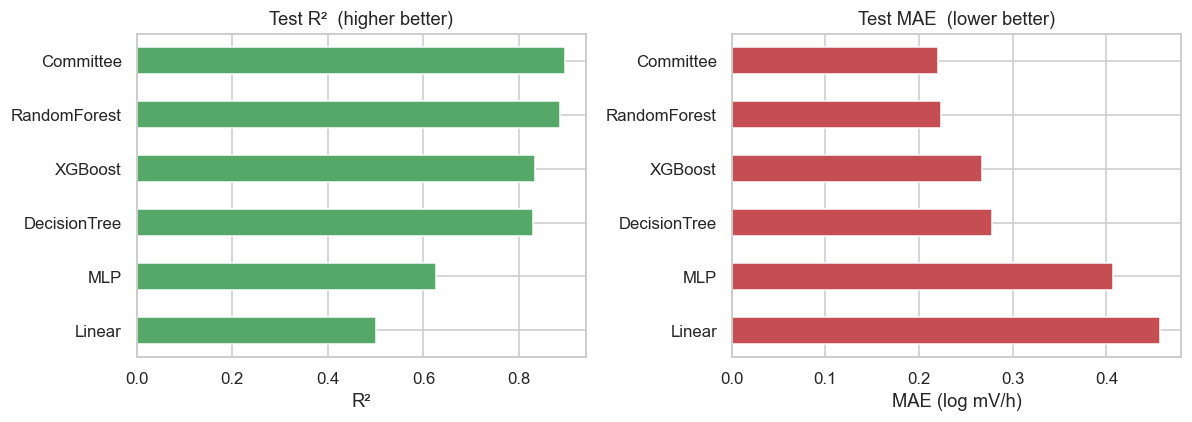

In [9]:
comp = pd.DataFrame({k: {"R2": v["R2"], "MAE": v["MAE"]} for k, v in results.items()}).T
order = comp["R2"].sort_values().index
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
comp.loc[order, "R2"].plot.barh(ax=ax[0], color="#55A868"); ax[0].set(title="Test R²  (higher better)", xlabel="R²")
comp.loc[order, "MAE"].plot.barh(ax=ax[1], color="#C44E52"); ax[1].set(title="Test MAE  (lower better)", xlabel="MAE (log mV/h)")
fig.tight_layout(); fig.savefig("figures/1b_02_model_comparison.png", dpi=150); plt.show()

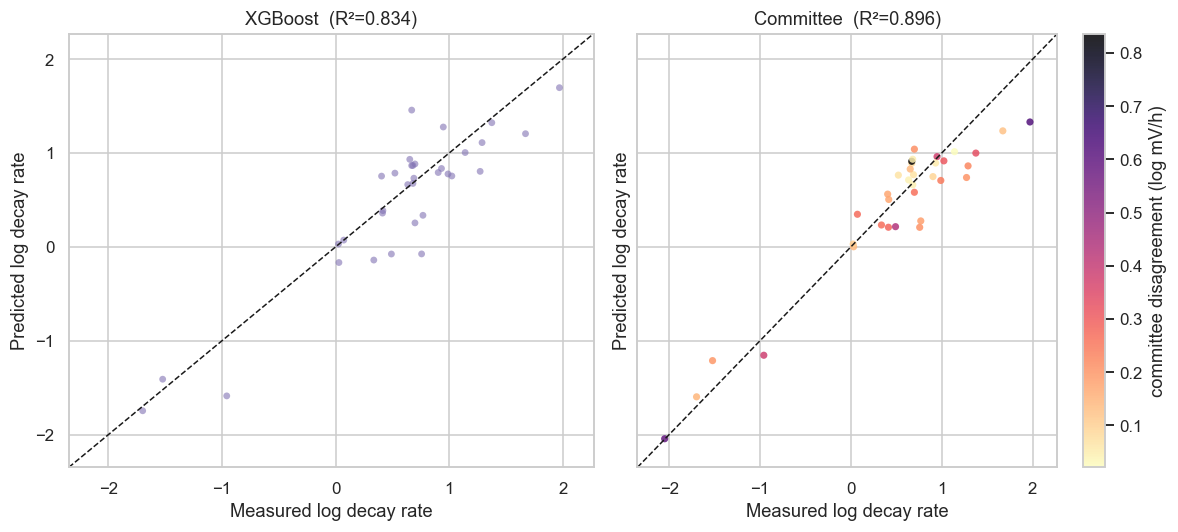

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
lims = [y_te.min() - 0.3, y_te.max() + 0.3]
ax[0].scatter(y_te, results["XGBoost"]["pred"], s=20, alpha=0.6, color="#8172B3", edgecolor="none")
ax[0].set(title=f"XGBoost  (R²={results['XGBoost']['R2']:.3f})")
sc = ax[1].scatter(y_te, ens_pred, c=ens_std, s=22, alpha=0.85, cmap="magma_r", edgecolor="none")
ax[1].set(title=f"Committee  (R²={results['Committee']['R2']:.3f})")
fig.colorbar(sc, ax=ax[1], label="committee disagreement (log mV/h)")
for a in ax:
    a.plot(lims, lims, "k--", lw=1); a.set(xlim=lims, ylim=lims,
        xlabel="Measured log decay rate", ylabel="Predicted log decay rate")
fig.tight_layout(); fig.savefig("figures/1b_03_parity.png", dpi=150); plt.show()

### Use the model: predict a recipe's stability

Same idea as 1a: define a recipe, get a predicted log decay rate and the committee's uncertainty (lower is more stable).

In [11]:
def predict_recipe(metals, proportions, **conditions):
    row = X_tr.median().copy()
    for i in range(4):
        sym = metals[i] if i < len(metals) else "None"
        for p, val in zip(PROPS, element_information.get(sym, element_information["None"])):
            row[f"M{i+1}:{p}"] = val
        row[f"Metal_Dopant_{i+1} Proportion in Precursor"] = proportions[i] if i < len(proportions) else 0.0
    for k, v in conditions.items():
        if k in row.index: row[k] = v
    xq = row.to_frame().T
    p = {n: float(results[n]["model"].predict(xq)[0]) for n in ["RandomForest", "XGBoost", "MLP"]}
    vals = np.array(list(p.values()))
    return vals.mean(), vals.std(), p

mu, sd, members = predict_recipe(["Ru", "Ir"], [60, 40], **{"Stability Test Time (h)": 24})
print(f"Predicted log decay rate = {mu:.2f} ± {sd:.2f}   (lower = more stable)")
for n, v in members.items(): print(f"   {n:13s} {v:.2f}")

Predicted log decay rate = 0.01 ± 0.56   (lower = more stable)
   RandomForest  0.21
   XGBoost       -0.76
   MLP           0.57


## 4. What drives stability: SHAP

Same SHAP read-out as 1a. The question worth asking: do the factors that drive activity also drive stability?

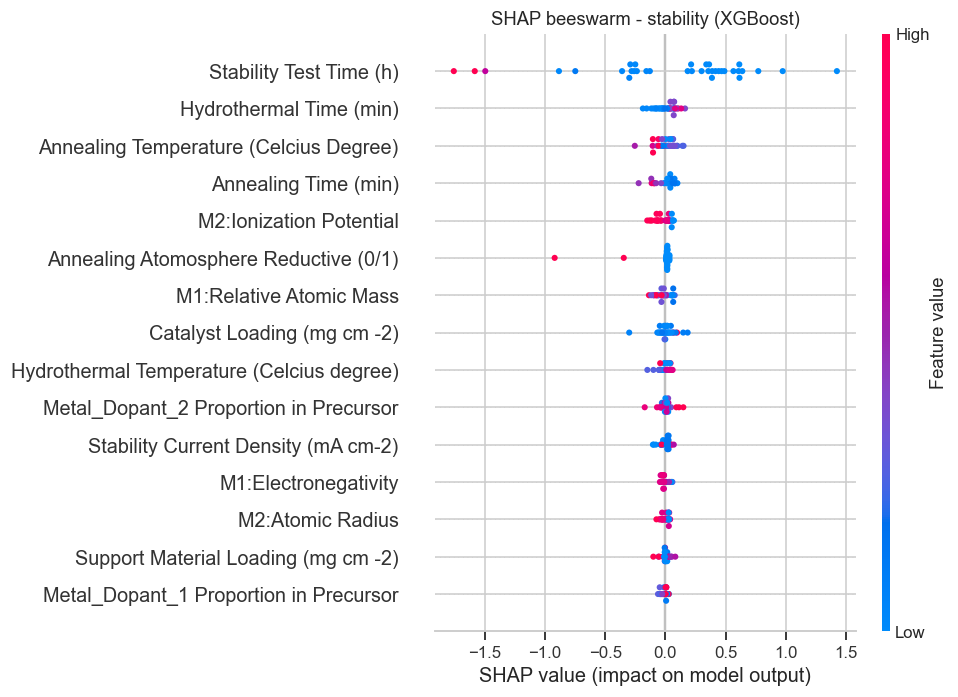

Top-10 features (stability):
Stability Test Time (h)                      0.557
Hydrothermal Time (min)                      0.067
Annealing Temperature (Celcius Degree)       0.060
Annealing Time (min)                         0.060
M2:Ionization Potential                      0.053
Annealing Atomosphere Reductive (0/1)        0.052
M1:Relative Atomic Mass                      0.051
Catalyst Loading (mg cm -2)                  0.047
Hydrothermal Temperature (Celcius degree)    0.035
Metal_Dopant_2 Proportion in Precursor       0.032


In [12]:
import shap
Xs = X_te.sample(min(300, len(X_te)), random_state=RND)
sv = shap.TreeExplainer(results["XGBoost"]["model"]).shap_values(Xs)
shap.summary_plot(sv, Xs, max_display=15, show=False)
plt.gcf().set_size_inches(9, 6.5); plt.title("SHAP beeswarm - stability (XGBoost)")
plt.tight_layout(); plt.savefig("figures/1b_04_shap_beeswarm.png", dpi=150, bbox_inches="tight"); plt.show()
imp = pd.Series(np.abs(sv).mean(0), index=Xs.columns).sort_values(ascending=False)
print("Top-10 features (stability):"); print(imp.head(10).round(3).to_string())

**Read it against Module 1a.** The top stability drivers are not the same as the top activity drivers, and they include the stability-test conditions (current density, test time), which strongly shape the measured decay rate. That is the same confounder warning as before: testing conditions leak into literature-mined data. The materials takeaway is that a highly active catalyst is not automatically a durable one. Activity and stability are governed by partly different factors, which is why the paper models them separately.

> **Try it: confounder check.** `Stability Test Time` tops the SHAP ranking, but it is a testing choice, not the material. Drop the stability-test columns and re-fit: the R² you lose shows how much the model keyed on the test protocol rather than the catalyst.

In [13]:
test_cond = [c for c in ["Stability Test Time (h)", "Stability Current Density (mA cm-2)",
                         "Catalyst Loading (mg cm -2)"] if c in X.columns]
keep = [c for c in X.columns if c not in test_cond]
mat = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8,
                   colsample_bytree=0.8, random_state=RND, n_jobs=-1).fit(X_tr[keep], y_tr)
print(f"full model                          R2 = {results['XGBoost']['R2']:.3f}")
print(f"material-only (dropped {len(test_cond)} test cols) R2 = {r2_score(y_te, mat.predict(X_te[keep])):.3f}")

full model                          R2 = 0.834
material-only (dropped 3 test cols) R2 = 0.509


## 5. Wrap-up

- **Same template, new target.** Only `DATA_PATH`, encoding, `TARGET`, `META_DROP`, and the split seed changed; everything else is copied from Module 1a. Tree ensembles again lead (test R² roughly 0.83 to 0.90), reproducing the paper. Here the committee even edges out the best single model (unlike 1a), because the MLP is less weak on this target and adds complementary signal.
- **Activity is not stability.** The SHAP rankings differ, so optimizing for low overpotential alone can miss durability. Model both.
- **A caveat worth teaching:** the high-quality stability set is small (345 rows, 35 in test), so a single split is noisier than 1a. Treat the exact number as indicative.

## Source and citation

This module is a teaching rewrite of the data-mining workflow from:

> R. Ding, J. Liu, K. Hua, X. Wang, X. Zhang, M. Shao, Y. Chen, J. Chen,
> "Leveraging data mining, active learning, and domain adaptation for efficient discovery of advanced oxygen evolution electrocatalysts,"
> *Science Advances* **11**, eadr9038 (2025). doi:[10.1126/sciadv.adr9038](https://www.science.org/doi/full/10.1126/sciadv.adr9038)

- Code and data (DASH repo): https://github.com/ruiding-uchicago/DASH
- Dataset archive (Dryad): doi:10.5061/dryad.nk98sf83g

Released for educational use; please cite the paper above if you build on this material.